# CELDA 1 — Configuración del entorno

En esta celda importamos todas las librerías necesarias para el proyecto,
configuramos matplotlib para visualizaciones y mostramos los tickers disponibles.

In [4]:
# =============================================================================
# CELDA 1 — Configuración del entorno
# =============================================================================

# Importaciones principales
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(font_scale=1.2)
warnings.filterwarnings('ignore')

# Añadir directorio src al path
sys.path.append(os.path.join('..', 'src'))

# Importar módulos del proyecto
import data_collection as dc
import preprocessing as pp
import feature_engineering as fe
import event_study as es

# Mostrar tickers disponibles
print("TICKERS DISPONIBLES:")
for nombre, simbolo in dc.TICKERS.items():
    print(f"  {nombre}: {simbolo}")

print("\nConfiguración del entorno completada.")

TICKERS DISPONIBLES:
  SP500: ^GSPC
  VIX: ^VIX
  BRENT: BZ=F
  WTI: CL=F
  COLCAP: ^COLCAP
  BOVESPA: ^BVSP
  IBVC: ^IBVC
  MERVAL: ^MERV
  USD_COP: USDCOP=X
  GOLD: GC=F
  COPPER: HG=F
  EXXON: XOM
  CHEVRON: CVX

Configuración del entorno completada.


# CELDA 2 — Parámetros de descarga

Definimos las fechas de inicio y fin para la descarga de datos,
así como la fecha del evento (captura de Maduro).

In [5]:
# =============================================================================
# CELDA 2 — Parámetros de descarga
# =============================================================================

# Fechas de descarga
START_DATE = "2020-01-01"
END_DATE = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
EVENT_DATE = "2026-01-03"
EVENT_DATE_HABIL = "2026-01-05"  # primer día hábil post-captura

print(f"Fecha de inicio: {START_DATE}")
print(f"Fecha de fin: {END_DATE}")
print(f"Fecha del evento: {EVENT_DATE}")
print(f"Primer día hábil post-evento: {EVENT_DATE_HABIL}")

Fecha de inicio: 2020-01-01
Fecha de fin: 2026-04-20
Fecha del evento: 2026-01-03
Primer día hábil post-evento: 2026-01-05


# CELDA 3 — Descarga de datos

Descargamos los precios de cierre ajustados desde Yahoo Finance
para todos los activos financieros definidos en el diccionario TICKERS,
incluyendo las bolsas de Venezuela (IBVC) y Argentina (MERVAL).

In [6]:
# =============================================================================
# CELDA 3 — Descarga de datos
# =============================================================================

# Descargar datos
df_precios = dc.descargar_datos(dc.TICKERS, START_DATE, END_DATE)

# Mostrar primeras filas
print("\nPrimeras filas del DataFrame de precios:")
print(df_precios.head())

# Guardar datos crudos
dc.guardar_datos(df_precios, "precios_diarios")


DESCARGANDO DATOS FINANCIEROS: 2020-01-01 hasta 2026-04-20
Descargando SP500 (^GSPC)...
✓ SP500: 1581 registros descargados
Descargando VIX (^VIX)...
✓ VIX: 1581 registros descargados
Descargando BRENT (BZ=F)...
✓ BRENT: 1584 registros descargados
Descargando WTI (CL=F)...
✓ WTI: 1583 registros descargados
Descargando COLCAP (^COLCAP)...


2026-04-21 09:07:44,743 - yfinance - ERROR - HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^COLCAP"}}}
2026-04-21 09:07:45,002 - yfinance - ERROR - $^COLCAP: possibly delisted; no timezone found
2026-04-21 09:07:45,003 - yfinance - ERROR - 
1 Failed download:
2026-04-21 09:07:45,016 - yfinance - ERROR - ['^COLCAP']: possibly delisted; no timezone found


⚠️ No se encontraron datos para COLCAP (^COLCAP)
Descargando BOVESPA (^BVSP)...
✓ BOVESPA: 1567 registros descargados
Descargando IBVC (^IBVC)...


2026-04-21 09:07:51,170 - yfinance - ERROR - HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^IBVC"}}}
2026-04-21 09:07:51,436 - yfinance - ERROR - $^IBVC: possibly delisted; no timezone found
2026-04-21 09:07:51,454 - yfinance - ERROR - 
1 Failed download:
2026-04-21 09:07:51,458 - yfinance - ERROR - ['^IBVC']: possibly delisted; no timezone found


⚠️ No se encontraron datos para IBVC (^IBVC)
Descargando MERVAL (^MERV)...
✓ MERVAL: 1531 registros descargados
Descargando USD_COP (USDCOP=X)...
✓ USD_COP: 1638 registros descargados
Descargando GOLD (GC=F)...
✓ GOLD: 1583 registros descargados
Descargando COPPER (HG=F)...
✓ COPPER: 1584 registros descargados
Descargando EXXON (XOM)...
✓ EXXON: 1581 registros descargados
Descargando CHEVRON (CVX)...
✓ CHEVRON: 1581 registros descargados

RESUMEN DE DESCARGA:
- Período: 2020-01-01 a 2026-04-20
- Shape: (1639, 11)
- Rango de fechas: 2020-01-01 00:00:00 a 2026-04-17 00:00:00
- Activos descargados: SP500, VIX, BRENT, WTI, BOVESPA, MERVAL, USD_COP, GOLD, COPPER, EXXON, CHEVRON

Primeras filas del DataFrame de precios:
                  SP500    VIX      BRENT        WTI   BOVESPA   MERVAL  \
Date                                                                      
2020-01-01          NaN    NaN        NaN        NaN       NaN      NaN   
2020-01-02  3257.850098  12.47  66.250000  61.18000

'data\\processed\\precios_diarios.csv'

# CELDA 4 — Validación de calidad inicial

Realizamos una validación completa de la calidad de los datos descargados,
verificando precios negativos, fechas duplicadas y valores nulos.

In [7]:
# =============================================================================
# CELDA 4 — Validación de calidad inicial
# =============================================================================

# Validar calidad de datos
metricas_calidad = dc.validar_calidad_datos(df_precios)

# Mostrar resumen de nulos
print("\nResumen de valores nulos por columna:")
for col, nulos in metricas_calidad['nulos'].items():
    porcentaje = metricas_calidad['porcentaje_nulos'][col]
    print(f"  {col}: {nulos} nulos ({porcentaje:.2f}%)")


VALIDACIÓN DE CALIDAD DE DATOS
⚠️ ADVERTENCIA: Se encontraron precios negativos:
WTI    1
dtype: int64
✓ No se encontraron fechas duplicadas
⚠️ ADVERTENCIA: Se encontraron valores nulos:
  - SP500: 58 nulos (3.54%)
  - VIX: 58 nulos (3.54%)
  - BRENT: 55 nulos (3.36%)
  - WTI: 56 nulos (3.42%)
  - BOVESPA: 72 nulos (4.39%)
  - MERVAL: 108 nulos (6.59%)
  - USD_COP: 1 nulos (0.06%)
  - GOLD: 56 nulos (3.42%)
  - COPPER: 55 nulos (3.36%)
  - EXXON: 58 nulos (3.54%)
  - CHEVRON: 58 nulos (3.54%)

RESUMEN ESTADÍSTICO:
- Número de registros: 1639
- Número de columnas: 11
- Rango de fechas: 2020-01-01 00:00:00 a 2026-04-17 00:00:00

Resumen de valores nulos por columna:
  SP500: 58 nulos (3.54%)
  VIX: 58 nulos (3.54%)
  BRENT: 55 nulos (3.36%)
  WTI: 56 nulos (3.42%)
  BOVESPA: 72 nulos (4.39%)
  MERVAL: 108 nulos (6.59%)
  USD_COP: 1 nulos (0.06%)
  GOLD: 56 nulos (3.42%)
  COPPER: 55 nulos (3.36%)
  EXXON: 58 nulos (3.54%)
  CHEVRON: 58 nulos (3.54%)


# CELDA 5 — Visualización de precios históricos normalizados

Graficamos los precios históricos normalizados (indexados a 100) para
diferentes grupos de activos: índices bursátiles, petróleo, acciones y metales.

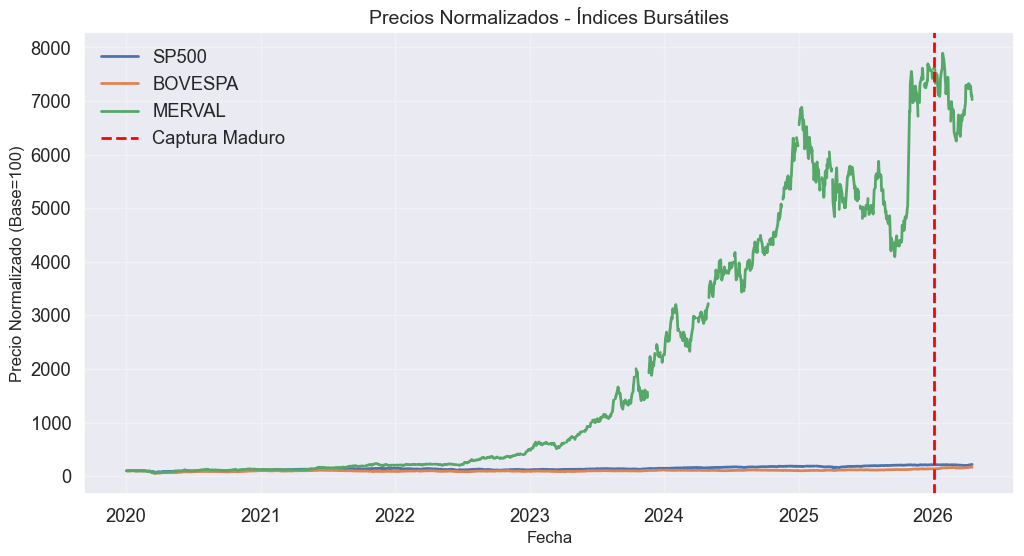

Gráfico de Índices Bursátiles guardado en: ..\data\processed\graficos\precios_normalizados_índices_bursátiles.png


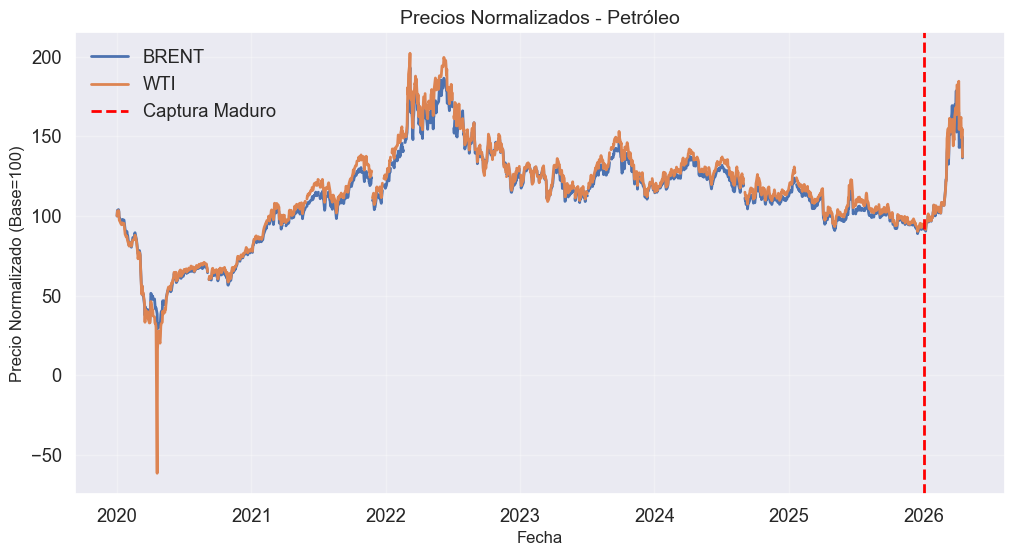

Gráfico de Petróleo guardado en: ..\data\processed\graficos\precios_normalizados_petróleo.png


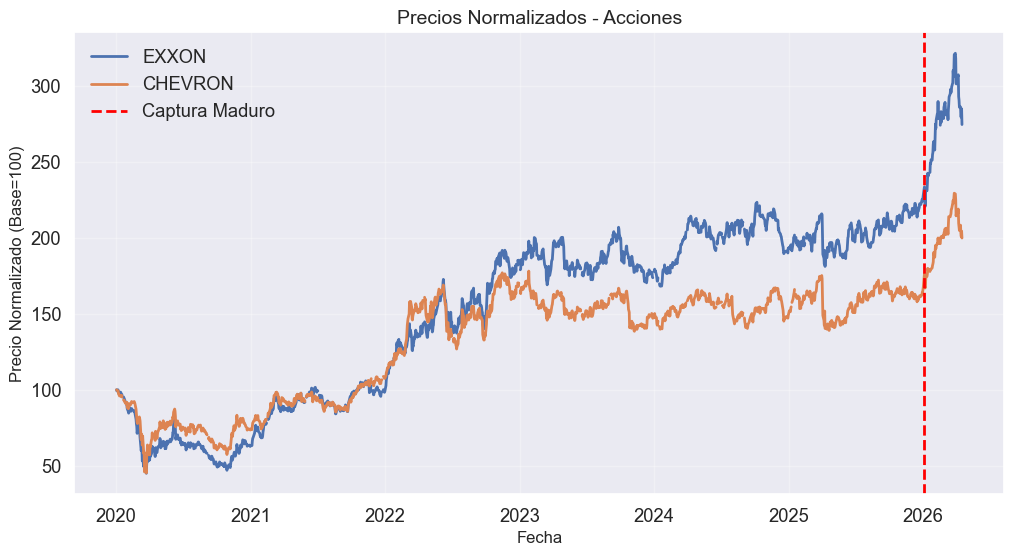

Gráfico de Acciones guardado en: ..\data\processed\graficos\precios_normalizados_acciones.png


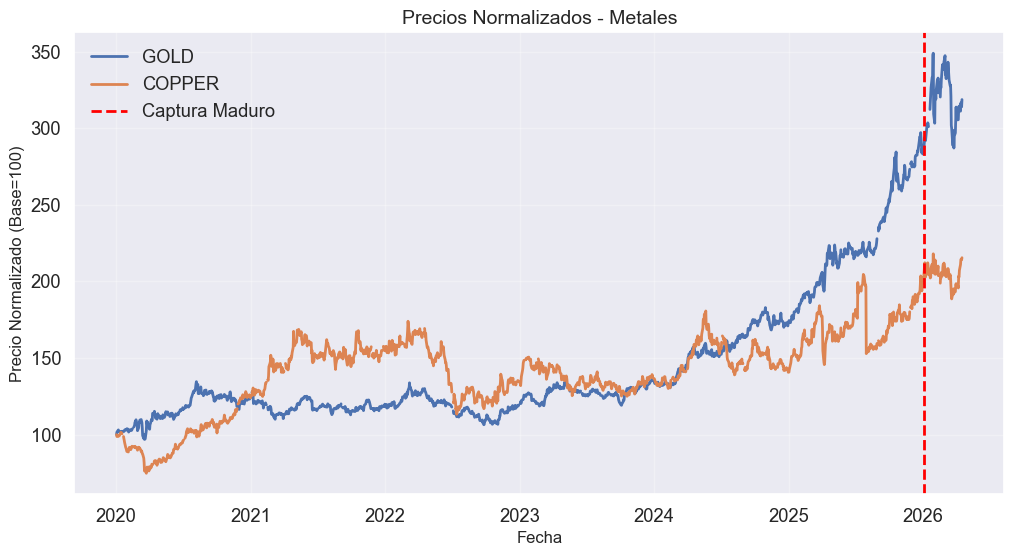

Gráfico de Metales guardado en: ..\data\processed\graficos\precios_normalizados_metales.png


In [8]:
# =============================================================================
# CELDA 5 — Visualización de precios históricos normalizados
# =============================================================================

# Normalizar precios a 100
# Usar el primer valor válido de cada columna como base
primeros_valores_validos = df_precios.bfill().iloc[0]
df_normalizado = df_precios / primeros_valores_validos * 100

# Definir grupos de activos
grupos = {
    'Índices Bursátiles': ['SP500', 'COLCAP', 'BOVESPA', 'IBVC', 'MERVAL'],
    'Petróleo': ['BRENT', 'WTI'],
    'Acciones': ['EXXON', 'CHEVRON'],
    'Metales': ['GOLD', 'COPPER']
}

# Crear directorio para gráficos si no existe
os.makedirs(os.path.join('..', 'data', 'processed', 'graficos'), exist_ok=True)

# Graficar cada grupo
for nombre_grupo, activos in grupos.items():
    plt.figure(figsize=(12, 6))
    
    for activo in activos:
        if activo in df_normalizado.columns:
            plt.plot(df_normalizado.index, df_normalizado[activo], label=activo, linewidth=2)
    
    # Línea vertical en el evento
    plt.axvline(x=pd.to_datetime(EVENT_DATE), color='red', linestyle='--', 
                linewidth=2, label='Captura Maduro')
    
    # Configurar gráfico
    plt.title(f'Precios Normalizados - {nombre_grupo}', fontsize=14)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio Normalizado (Base=100)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Guardar gráfico
    ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 
                                f'precios_normalizados_{nombre_grupo.lower().replace(" ", "_")}.png')
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Gráfico de {nombre_grupo} guardado en: {ruta_guardado}")

# CELDA 6 — Cálculo de retornos logarítmicos

Calculamos los retornos logarítmicos diarios para cada activo financiero
y mostramos estadísticas básicas de los retornos.

In [9]:
# =============================================================================
# CELDA 6 — Cálculo de retornos logarítmicos
# =============================================================================

import numpy as np

# Calcular retornos logarítmicos
df_retornos = np.log(df_precios / df_precios.shift(1))

# Eliminar primera fila NaN
df_retornos = df_retornos.dropna()

# Mostrar primeras filas
print("\nPrimeras filas del DataFrame de retornos:")
print(df_retornos.head())

# Mostrar estadísticas básicas
print("\nEstadísticas básicas de retornos:")
print(df_retornos.describe())

# Guardar retornos
dc.guardar_datos(df_retornos, "retornos_diarios")


Primeras filas del DataFrame de retornos:
               SP500       VIX     BRENT       WTI   BOVESPA    MERVAL  \
Date                                                                     
2020-01-03 -0.007085  0.117159  0.034857  0.030108 -0.007330 -0.014901   
2020-01-06  0.003527 -0.012200  0.004509  0.003483 -0.007068  0.023693   
2020-01-07 -0.002807 -0.004342 -0.009331 -0.009050 -0.001850 -0.008573   
2020-01-08  0.004890 -0.024965 -0.042337 -0.050538 -0.003564 -0.002435   
2020-01-09  0.006633 -0.070056 -0.001070 -0.000839 -0.002584  0.024564   

             USD_COP      GOLD    COPPER     EXXON   CHEVRON  
Date                                                          
2020-01-03 -0.008269  0.016072 -0.012253 -0.008072 -0.003465  
2020-01-06  0.001275  0.010914  0.000714  0.007649 -0.003394  
2020-01-07 -0.003827  0.003569  0.001249 -0.008218 -0.012852  
2020-01-08  0.009140 -0.009204  0.005335 -0.015195 -0.011488  
2020-01-09 -0.010438 -0.003667 -0.003020  0.007626 -0.001616

'data\\processed\\retornos_diarios.csv'

# CELDA 7 — Imputación de valores nulos

Imputamos los valores nulos en los retornos utilizando diferentes estrategias
(forward fill, backward fill, interpolación lineal) y guardamos el resultado.

In [10]:
# =============================================================================
# CELDA 7 — Imputación de valores nulos
# =============================================================================

import pandas as pd

# Copiar DataFrame de retornos
df_retornos_imputados = df_retornos.copy()

# Imputación combinada para series temporales financieras
# 1. Forward Fill (rellena con valor anterior)
df_retornos_imputados = df_retornos_imputados.fillna(method='ffill')

# 2. Backward Fill (rellena con valor posterior si quedan huecos al inicio)
df_retornos_imputados = df_retornos_imputados.fillna(method='bfill')

# Verificar que no quedan nulos
nulos_restantes = df_retornos_imputados.isnull().sum().sum()
print(f"\nValores nulos restantes después de imputación: {nulos_restantes}")

# Mostrar nulos por columna
print("\nNulos por columna:")
print(df_retornos_imputados.isnull().sum())

# Mostrar primeras filas
print("\nPrimeras filas del DataFrame de retornos imputados:")
print(df_retornos_imputados.head())

# Guardar retornos imputados
dc.guardar_datos(df_retornos_imputados, "retornos_imputados")

print("\nDatos de retornos imputados guardados correctamente.")


Valores nulos restantes después de imputación: 0

Nulos por columna:
SP500      0
VIX        0
BRENT      0
WTI        0
BOVESPA    0
MERVAL     0
USD_COP    0
GOLD       0
COPPER     0
EXXON      0
CHEVRON    0
dtype: int64

Primeras filas del DataFrame de retornos imputados:
               SP500       VIX     BRENT       WTI   BOVESPA    MERVAL  \
Date                                                                     
2020-01-03 -0.007085  0.117159  0.034857  0.030108 -0.007330 -0.014901   
2020-01-06  0.003527 -0.012200  0.004509  0.003483 -0.007068  0.023693   
2020-01-07 -0.002807 -0.004342 -0.009331 -0.009050 -0.001850 -0.008573   
2020-01-08  0.004890 -0.024965 -0.042337 -0.050538 -0.003564 -0.002435   
2020-01-09  0.006633 -0.070056 -0.001070 -0.000839 -0.002584  0.024564   

             USD_COP      GOLD    COPPER     EXXON   CHEVRON  
Date                                                          
2020-01-03 -0.008269  0.016072 -0.012253 -0.008072 -0.003465  
2020-01-06  0

# CELDA 8 — Análisis de outliers

Identificamos y visualizamos los outliers en los retornos utilizando
el método IQR (Rango Intercuartílico).


Resumen de outliers por columna:
  SP500: 68 outliers (5.13%)
  VIX: 67 outliers (5.06%)
  BRENT: 70 outliers (5.28%)
  WTI: 63 outliers (4.75%)
  BOVESPA: 41 outliers (3.09%)
  MERVAL: 35 outliers (2.64%)
  USD_COP: 31 outliers (2.34%)
  GOLD: 73 outliers (5.51%)
  COPPER: 38 outliers (2.87%)
  EXXON: 52 outliers (3.92%)
  CHEVRON: 69 outliers (5.21%)


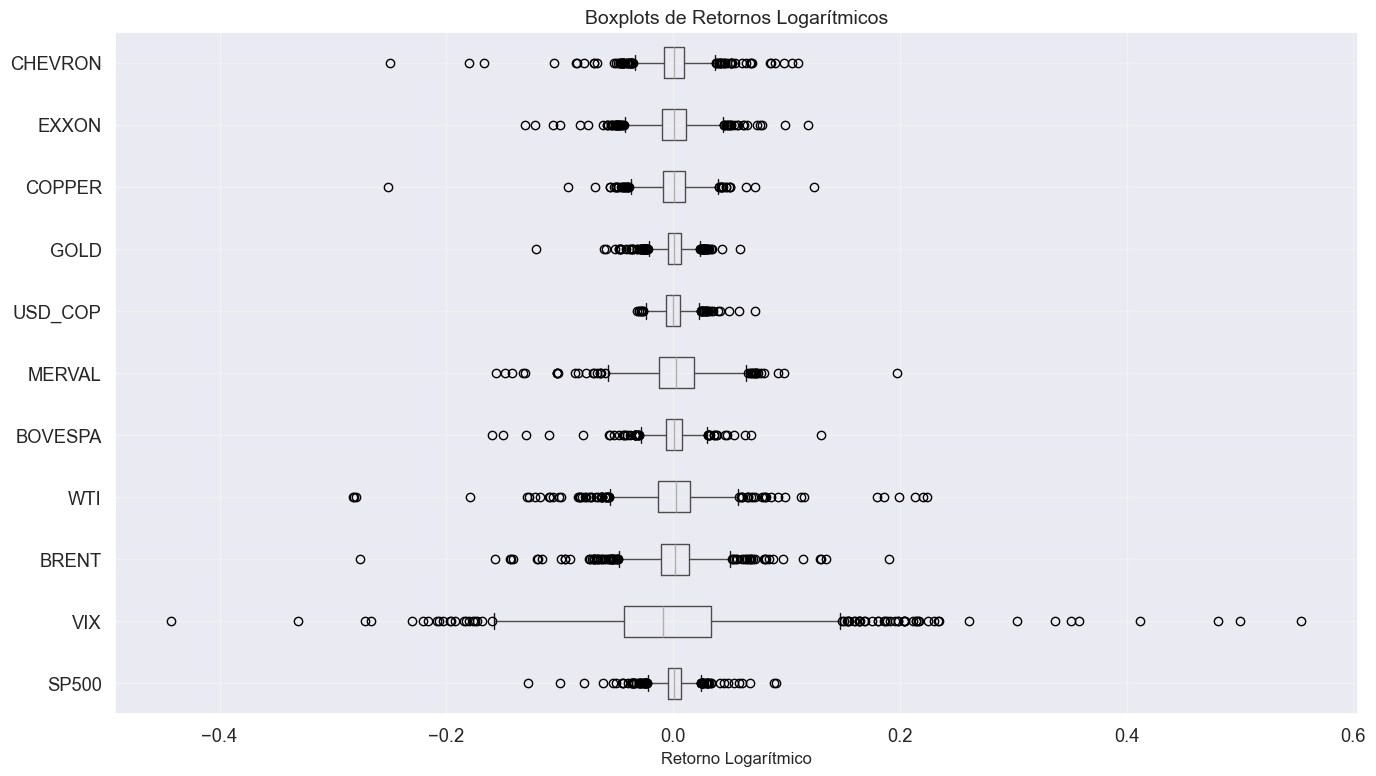


Gráfico de boxplots guardado en: ..\data\processed\graficos\boxplots_outliers.png


In [11]:
# =============================================================================
# CELDA 8 — Análisis de outliers
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# Diccionario para guardar resultados
outliers = {}

# Detectar outliers con método IQR
for col in df_retornos_imputados.columns:
    
    Q1 = df_retornos_imputados[col].quantile(0.25)
    Q3 = df_retornos_imputados[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    condicion_outlier = (df_retornos_imputados[col] < limite_inferior) | (df_retornos_imputados[col] > limite_superior)
    
    cantidad = condicion_outlier.sum()
    porcentaje = (cantidad / len(df_retornos_imputados)) * 100
    
    outliers[col] = {
        'cantidad': int(cantidad),
        'porcentaje': porcentaje
    }

# Mostrar resumen
print("\nResumen de outliers por columna:")
for col, info in outliers.items():
    print(f"  {col}: {info['cantidad']} outliers ({info['porcentaje']:.2f}%)")


# =============================================================================
# Visualización de outliers
# =============================================================================

plt.figure(figsize=(14, 8))
df_retornos_imputados.boxplot(vert=False)

plt.title('Boxplots de Retornos Logarítmicos', fontsize=14)
plt.xlabel('Retorno Logarítmico', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Crear carpeta si no existe
os.makedirs(os.path.join('..', 'data', 'processed', 'graficos'), exist_ok=True)

# Guardar gráfico
ruta_guardado = os.path.join(
    '..', 'data', 'processed', 'graficos', 'boxplots_outliers.png'
)

plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de boxplots guardado en: {ruta_guardado}")

# CELDA 9 — Análisis de correlación

Calculamos y visualizamos la matriz de correlación entre los retornos
de los diferentes activos financieros.

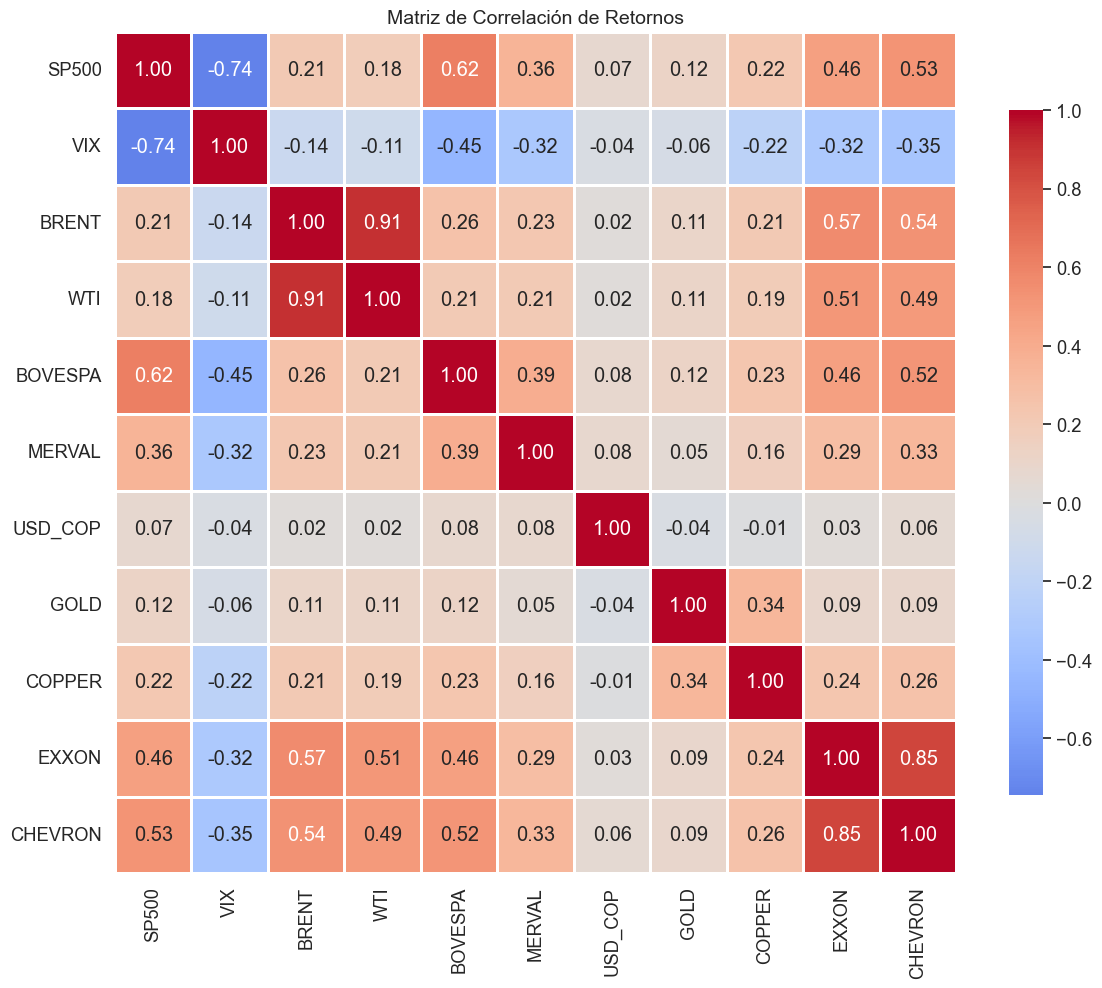


Matriz de correlación guardada en: ..\data\processed\graficos\matriz_correlacion.png

Correlaciones más altas:
  BRENT - WTI: 0.9072
  EXXON - CHEVRON: 0.8483
  SP500 - VIX: -0.7427
  SP500 - BOVESPA: 0.6159
  BRENT - EXXON: 0.5710
  BRENT - CHEVRON: 0.5361
  SP500 - CHEVRON: 0.5300
  BOVESPA - CHEVRON: 0.5205
  WTI - EXXON: 0.5148
  WTI - CHEVRON: 0.4912


In [12]:
# =============================================================================
# CELDA 9 — Análisis de correlación
# =============================================================================

# Calcular matriz de correlación
matriz_correlacion = df_retornos_imputados.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Retornos', fontsize=14)
plt.tight_layout()

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'matriz_correlacion.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMatriz de correlación guardada en: {ruta_guardado}")

# Mostrar correlaciones más altas
print("\nCorrelaciones más altas:")
pares_correlacion = []
for i in range(len(matriz_correlacion.columns)):
    for j in range(i+1, len(matriz_correlacion.columns)):
        pares_correlacion.append((
            matriz_correlacion.columns[i],
            matriz_correlacion.columns[j],
            matriz_correlacion.iloc[i, j]
        ))

pares_correlacion.sort(key=lambda x: abs(x[2]), reverse=True)
for par in pares_correlacion[:10]:
    print(f"  {par[0]} - {par[1]}: {par[2]:.4f}")

# CELDA 10 — Resumen y conclusiones

Resumimos los hallazgos principales de la preparación de datos
y los archivos generados.

In [13]:
# =============================================================================
# CELDA 10 — Resumen y conclusiones
# =============================================================================

print("="*80)
print("RESUMEN DE PREPARACIÓN DE DATOS")
print("="*80)

print(f"\nPeríodo de análisis: {START_DATE} a {END_DATE}")
print(f"Fecha del evento: {EVENT_DATE}")
print(f"Número de activos: {len(df_precios.columns)}")
print(f"Activos incluidos: {', '.join(df_precios.columns)}")

print("\nArchivos generados:")
print("  - data/processed/precios_diarios.csv")
print("  - data/processed/retornos_diarios.csv")
print("  - data/processed/retornos_imputados.csv")

print("\nGráficos generados:")
print("  - data/processed/graficos/precios_normalizados_índices_bursátiles.png")
print("  - data/processed/graficos/precios_normalizados_petróleo.png")
print("  - data/processed/graficos/precios_normalizados_acciones.png")
print("  - data/processed/graficos/precios_normalizados_metales.png")
print("  - data/processed/graficos/boxplots_outliers.png")
print("  - data/processed/graficos/matriz_correlacion.png")

print("\n" + "="*80)
print("PREPARACIÓN DE DATOS COMPLETADA")
print("="*80)

RESUMEN DE PREPARACIÓN DE DATOS

Período de análisis: 2020-01-01 a 2026-04-20
Fecha del evento: 2026-01-03
Número de activos: 11
Activos incluidos: SP500, VIX, BRENT, WTI, BOVESPA, MERVAL, USD_COP, GOLD, COPPER, EXXON, CHEVRON

Archivos generados:
  - data/processed/precios_diarios.csv
  - data/processed/retornos_diarios.csv
  - data/processed/retornos_imputados.csv

Gráficos generados:
  - data/processed/graficos/precios_normalizados_índices_bursátiles.png
  - data/processed/graficos/precios_normalizados_petróleo.png
  - data/processed/graficos/precios_normalizados_acciones.png
  - data/processed/graficos/precios_normalizados_metales.png
  - data/processed/graficos/boxplots_outliers.png
  - data/processed/graficos/matriz_correlacion.png

PREPARACIÓN DE DATOS COMPLETADA
